# <img style="float: left; padding-right: 20px; width: 200px" src="https://raw.githubusercontent.com/raxlab/imt2200-data/main/media/logo.jpg">  IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

# <h1><center>Tarea 02: Extracción y Transformación de Datos </center></h1>

**Fecha de Entrega:** 25 de septiembre de 2025, a las 23:59.

**Fecha de publicación**: 2 de septiembre de 2025.

**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 02 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tarea.

- Deben hacer sus consultas y comentarios sobre la Tarea a través del canal de Tareas en el Foro del curso en Canvas.

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

Para esta tarea, queremos comprender y visualizar la distribución de aves migratorias en el territorio chileno. Específicamente, queremos entender las diferencias entre las migraciones de 2 especies en particular, el run-run y la dormilona tontita, a partir de los avistamientos registrados en eBird durante un periodo de 3 años y medio.

### 1.3 Recomendaciones
- Utiliza las librerías sugeridas en el notebook o justifica brevemente si incorporas otras.
- Revisa que todas las celdas se ejecuten en orden, desde el inicio, sin errores.
- Comenta tu código para explicar qué hace cada sección relevante.
- Asegúrate de que las visualizaciones sean fáciles de interpretar y tengan títulos y etiquetas adecuados.

### 1.4 Ejemplo de visualización

Esta tarea se enfoca en datos de aves. Para complementarla, les compartimos la siguiente página web, llamada "Bird Migration Explorer" que les permite visualizar, de una forma novedosa e interesante, las rutas de migración de aves en las Americas. Visiten la página para que vean cómo se puede visualizar datos de una manera interesante y novedosa, que podría ustedes usar en el futuro para sus proyectos.

In [1]:
from IPython.display import IFrame
IFrame("https://explorer.audubon.org/home?layersPanel=expand", width=900, height=600)

## 2. Datos

Los datos a utilizar provienen de la plataforma **[eBird](https://ebird.org/)**, una aplicación desarrollada por The Cornell Lab of Ornithology que permite a sus usuarios registrar y compartir avistamientos de aves en todo el mundo. La plataforma dispone de una API mediante la cual se pueden realizar consultas sobre avistamientos de aves recientes e históricos, especies según región, taxonomía, entre otros. 

### 2.1 Acceso a la API

Muchas API pueden utilizarse solo mediante el uso de una clave única, o "API key". Para conseguir una API key en eBird, primero debe ser usuario de la plataforma. Puede crear una cuenta aquí: https://secure.birds.cornell.edu/identity/account/create


Con una cuenta ya creada, puede ingresar a https://ebird.org/api/keygen para generar su llave. Debe llenar un formulario de solicitud al pedir su llave. Como sugerencia, puede llenar los campos con la siguiente información:

* **Organización:** Pontificia Universidad Católica de Chile
* **Título del Proyecto:** Tarea IMT2200 Introducción a Ciencia de Datos
* **Descripción:** "Uso educativo para exploración y análisis de distribución de aves migratorias en Chile."
* **Tipo de Proyecto:** Academic/Student
* **Casos de uso:** Materiales educativos y artíticos (...)

Debería recibir su llave inmediatamente después de enviar su solicitud. Como recomendación, puede revisar la documentación de la API en el siguiente link: https://documenter.getpostman.com/view/664302/S1ENwy59#intro

#### 2.2 Mapoteca de BCN

Para esta tarea queremos visualizar el movimiento de aves a lo largo de nuestro país. Para ello, también necesitaremos manejar datos geoespaciales: específicamente, trabajaremos con un mapa vectorial de Chile disponible en la página web de la Biblioteca del Congreso Nacional: https://www.bcn.cl/siit/mapas_vectoriales/index_html

Descargue el archivo `.zip` para las **Divisiones regionales** y descomprímalo. Dentro de esta carpeta, habrá un archivo llamado `Regional.shp`, que utilizaremos con `geopandas` para graficar nuestro mapa de Chile.

### 2.3 Librerías

Para esta tarea recomendamos al menos usar las librerías indicadas en la siguiente celda del Notebook. Puede agregar otras si lo estima conveniente para responder de mejor forma las preguntas de la Tarea.

In [2]:
import requests
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

## 3. Desarrollo

Para cada una de las siguientes preguntas o actividades incluya una o más celdas de código y Markdown con las respuestas o comentarios necesarios para contestar la pregunta o lograr la actividad. Agregue sus celdas a continuación de cada pregunta para que el Notebook quede ordenado.

En el caso de gráficos, figuras o tablas, asegúrese que todas tengan título, etiquetas en los ejes o haya claridad de los contenidos.

### 3.1 Extracción de datos (1.5 puntos)

**(1 pto)** Vamos a crear nuestra base de datos con los avistamientos registrados en eBird dentro de Chile desde 2022 hasta 2025. Revise la documentación de la API y averigue cómo extraer los avistamientos de un día. Luego extraiga los avistamientos para todos los días desde el **1 de enero de 2022 hasta el 31 de julio de 2025.** Cuando haya logrado extraer todos los datos, guárdelos en un archivo CSV o parquet.

Responda:

**a) (0.2 pts)** ¿Cuántos avistamientos tiene su dataset?

**b) (0.3 pts)** Obtenga la cantidad de veces que se repite cada especie en su dataset y ordénelas de mayor a menor. ¿Qué pasa con la cantidad de avistamientos según especie? ¿Por qué?

**Recomendaciones:** 
* Puede usar la librería `datetime` para generar fechas: cree una lista con todas las fechas e itere sobre esta lista para hacer los llamados a la API.
* **Pruebe primero con uno o dos días** para verificar el funcionamiento de su código y de la API.
* Inspeccione la forma en la que vienen los datos.
* Vaya guardando los datos extraídos en archivos (CSV o parquet), de modo que no tenga que repetir los llamados en caso de algún error.

**Hint**: Los códigos regionales chilenos para la API son los siguientes,
* `regionCode = CL`
* `sppLocale = es_CL` (para obtener nombres chilenos de las aves)

In [3]:
# Respuesta a

def create_date_list(start_date, end_date):
    dates = []
    start = datetime.strptime(start_date, "%Y/%m/%d")
    end = datetime.strptime(end_date, "%Y/%m/%d")
    
    num_days = (end - start).days + 1
    for i in range(num_days):
        dates.append(start + timedelta(days=i))
    return dates

dates = create_date_list("2022/01/01", "2025/07/31")
# REQUESTS
all_observations = []
for i in range(len(dates)):
    date_str = (dates[i].strftime("%Y/%m/%d"))
    url = f"https://api.ebird.org/v2/data/obs/CL/historic/{date_str}"

    headers = {
        "X-eBirdApiToken": "lkts3fs8lo5m"
    }
    params = {
        "sppLocale": "es_CL"
    }
    r = requests.get(url, headers=headers, params=params)
    data = r.json()
    df = pd.DataFrame(data)
    all_observations.append(df)
    

In [4]:
unified_df = pd.concat(all_observations, ignore_index=True)
unified_df.to_csv("datos_ebird_vicente_pardo.csv", index=False, encoding='utf-8')

start = dates[0].strftime("%d-%m-%Y")
end = dates[-1].strftime("%d-%m-%Y")

print(f"Cantidad de avistamientos entre {start} y el {end}: {len(unified_df)}")

Cantidad de avistamientos entre 01-01-2022 y el 31-07-2025: 272195


In [5]:
# Respuesta b
species_counts = unified_df["comName"].value_counts()
i = 1
print("50 especies que más se repiten en el dataset:\n")
for species, count in species_counts.items():
    if i > 50:
        break
    print(f"{i}) {species}: {count} veces")
    i += 1

50 especies que más se repiten en el dataset:

1) Tenca chilena: 1308 veces
2) Gaviota cáhuil: 1308 veces
3) Rara: 1308 veces
4) Churrete patagónico: 1308 veces
5) Rayadito: 1308 veces
6) Golondrina chilena: 1308 veces
7) Chercán común: 1308 veces
8) Tijeral común: 1308 veces
9) Yeco: 1308 veces
10) Loica común: 1308 veces
11) Jote de cabeza negra: 1308 veces
12) Jote de cabeza colorada: 1308 veces
13) Chirihue común: 1308 veces
14) Diucón: 1308 veces
15) Paloma doméstica: 1308 veces
16) Pelícano de Humboldt: 1308 veces
17) Tordo: 1308 veces
18) Paloma de alas blancas: 1308 veces
19) Gorrión: 1308 veces
20) Pato jergón chico: 1308 veces
21) Diuca común: 1308 veces
22) Garza grande: 1308 veces
23) Pato jergón grande: 1308 veces
24) Bandurria común: 1308 veces
25) Gaviota dominicana: 1308 veces
26) Tagua común: 1308 veces
27) Pilpilén común: 1308 veces
28) Cotorra: 1308 veces
29) Tiuque: 1308 veces
30) Queltehue común: 1308 veces
31) Chincol: 1308 veces
32) Tórtola: 1308 veces
33) Picafl

Lo que ocurre con la cantidad de avistamientos por especie es extraño, ya que el primer lugar es empatado por 38 especies con 1308 avistamientos cada una. Yo creo que esto pasa debido a que ebird tiene alguna especie de límite de entradas por especie, o algo similar.

### 3.2 Tranformación (1 punto)

**a) (0.5 pts)** Transforme la columna `obsDt` de string a un objeto de tipo `datetime` únicamente con año, mes y día (YYYY-MM-DD). Luego, agregue las siguientes nuevas columnas:
* `month` con únicamente el mes del avistamiento (puede dejar el mes como número entero de 1 a 12).
* `year-month` con el mes y año fecha en formato YYYY-MM

In [6]:
# Respuesta
#unified_df['obsDt']
unified_df["obsDt"] = pd.to_datetime(unified_df["obsDt"], format="mixed")
unified_df["month"] = unified_df["obsDt"].dt.month
unified_df["year-month"] = unified_df["obsDt"].dt.strftime("%Y-%m")
unified_df["obsDt"] = unified_df["obsDt"].dt.date
unified_df

,speciesCode,comName,sciName,locId,locName,obsDt,howMany,lat,lng,obsValid,obsReviewed,locationPrivate,subId,exoticCategory,month,year-month
0,soulap1,Queltehue común,Vanellus chilensis,L10140471,"Villa Parque Austral, Osorno, Región de los La...",2022-01-01,3.0,-40.585844,-73.113157,True,False,True,S99916680,NaN,1,2022-01
1,bkfibi1,Bandurria común,Theristicus melanopis,L7988120,"Leñadura, Nuestra casa",2022-01-01,4.0,-53.214573,-70.947665,True,False,True,S100024876,NaN,1,2022-01
2,grhowl2,Tucúquere,Bubo magellanicus,L7988120,"Leñadura, Nuestra casa",2022-01-01,1.0,-53.214573,-70.947665,True,False,True,S100024876,NaN,1,2022-01
3,austhr1,Zorzal patagónico,Turdus falcklandii,L7988120,"Leñadura, Nuestra casa",2022-01-01,1.0,-53.214573,-70.947665,True,False,True,S100024876,NaN,1,2022-01
4,rucspa1,Chincol,Zonotrichia capensis,L7988120,"Leñadura, Nuestra casa",2022-01-01,2.0,-53.214573,-70.947665,True,False,True,S100024876,NaN,1,2022-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272190,wbctyr1,Pitajo gris,Ochthoeca leucophrys,L570508,Putre,2025-07-31,2.0,-18.196454,-69.556568,True,False,False,S263980121,NaN,7,2025-07
272191,baytan3,Naranjero,Rauenia bonariensis,L570508,Putre,2025-07-31,2.0,-18.196454,-69.556568,True,False,False,S263980121,NaN,7,2025-07
272192,bktflo1,Comesebo negro,Diglossa brunneiventris,L570508,Putre,2025-07-31,1.0,-18.196454,-69.556568,True,False,False,S263980121,NaN,7,2025-07
272193,rngtyr1,Dormilona de nuca rojiza,Muscisaxicola rufivertex,L39684723,"Coronel Alcerreca, Arica y Parinacota, CL (-17...",2025-07-31,4.0,-17.992459,-69.660757,True,False,True,S264055602,NaN,7,2025-07


**b) (0.5 pts)** Averigue cómo tranformar su DataFrame de Pandas en un GeoDataFrame de GeoPandas. Para esto, utilice las columnas `lat`y `lng` para generar los puntos de la nueva columna `geometry`. Para las visualizaciones siguientes utilizaremos el Coordinate Reference System (CRS) EPSG 4326 (también llamado [WGS 84](https://es.wikipedia.org/wiki/WGS84)). Asegúrese que sus coordenadas correspondan a este CRS al crear su GeoDataFrame.

In [7]:
# Respuesta

'''
Prompt de IA:

How do i transform a Pandas DataFrame into a GeoPandas GeoDataFrame using 
the lat and lng columns to create geometry points using EPSG 3326 CRS?
'''
# Código generado por IA

from shapely.geometry import Point
# Create geometry points from lat and lng columns
# Note: Point() takes (longitude, latitude) - longitude first, then latitude
geometry = [Point(lng, lat) for lng, lat in zip(unified_df['lng'], unified_df['lat'])]

# Convert DataFrame to GeoDataFrame
gdf = gpd.GeoDataFrame(unified_df, geometry=geometry, crs='EPSG:4326')

# Fin código generado por IA

gdf["geometry"]

0         POINT (-73.11316 -40.58584)
1         POINT (-70.94766 -53.21457)
2         POINT (-70.94766 -53.21457)
3         POINT (-70.94766 -53.21457)
4         POINT (-70.94766 -53.21457)
                     ...             
272190    POINT (-69.55657 -18.19645)
272191    POINT (-69.55657 -18.19645)
272192    POINT (-69.55657 -18.19645)
272193    POINT (-69.66076 -17.99246)
272194    POINT (-69.52031 -18.18717)
Name: geometry, Length: 272195, dtype: geometry

### 3.3 Exploración del dataset (1 punto)

**a) (0.3 pts)** Utilice `geopandas` para leer el archivo `Regional.shp` descargado de BCN. Asegúrese de que su CRS sea el mismo que utilizó en la sección anterior.

In [8]:
# Respuesta
file = gpd.read_file("Regional.shp")
file.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [9]:
# Vemos que el CRS del archivo no es EPSG:4326, por lo que hay que cambiarlo.
file = file.to_crs("EPSG:4326")
file.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

**b) (0.7 pts)** Grafique un mapa de Chile con todos los avistamientos de su dataset como puntos en el mapa. Comente: ¿Cómo se distribuyen estos avistamientos? ¿Hay lugares en Chile donde haya una menor densidad de datos? ¿Cuáles? 

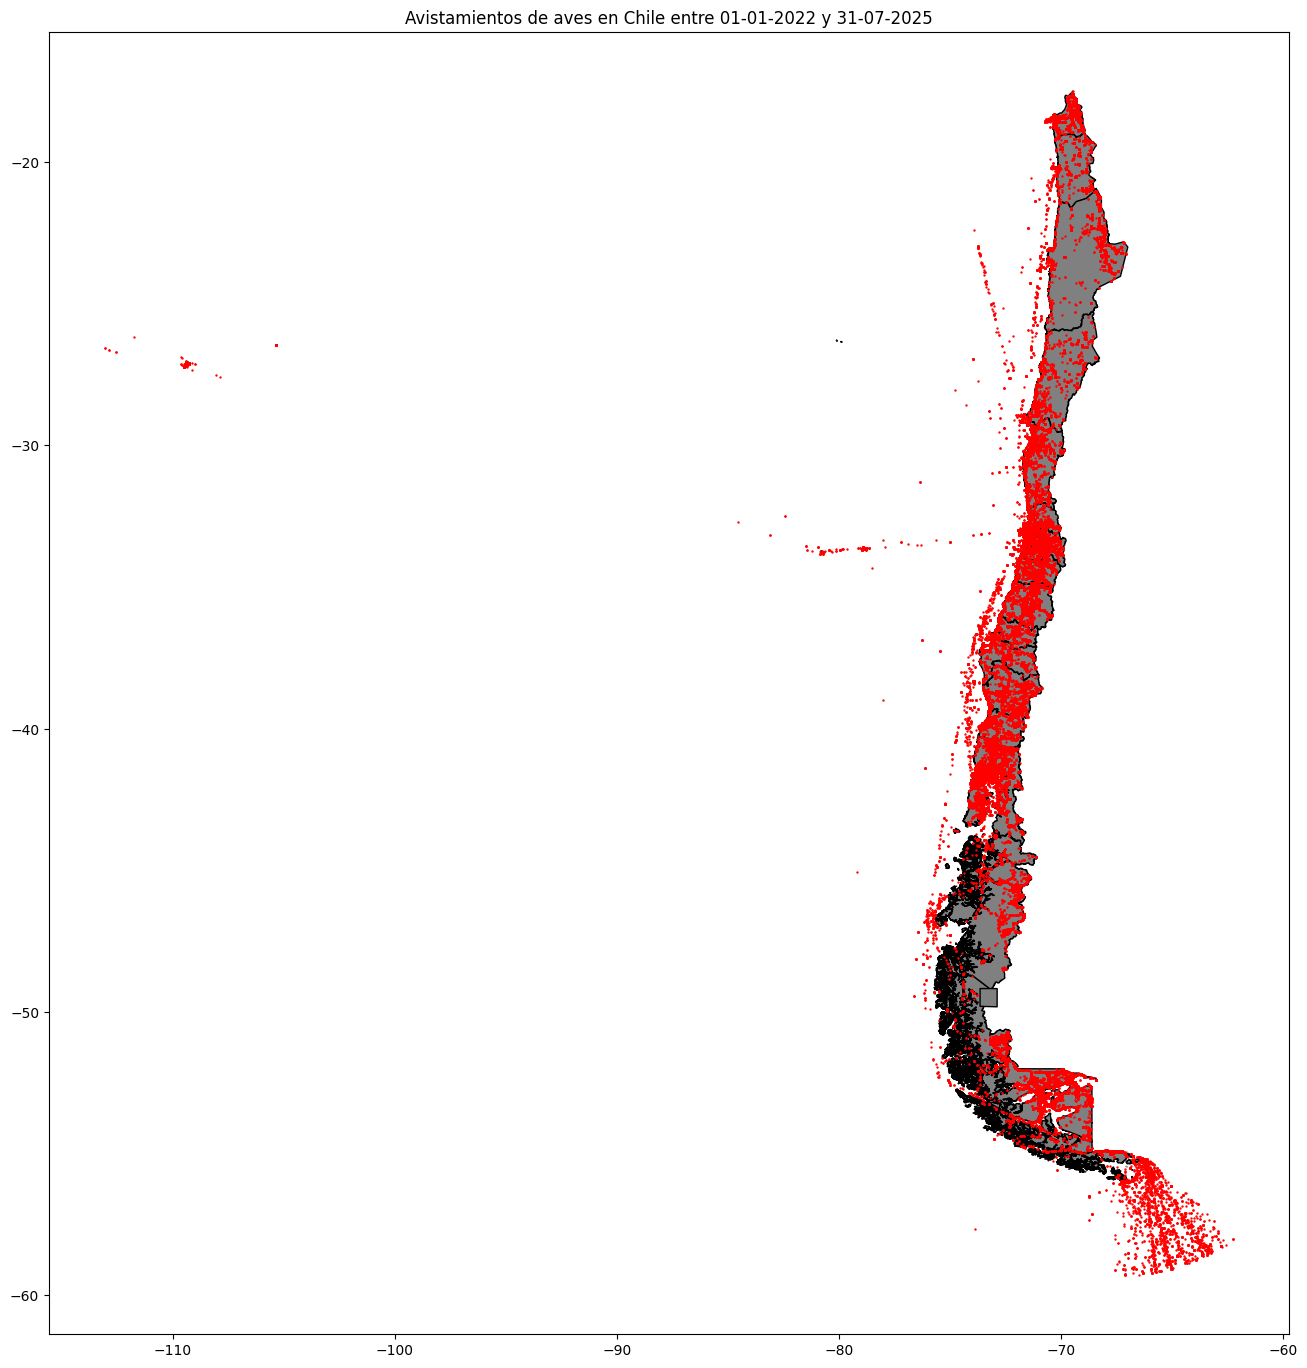

In [10]:
# Respuesta
fig = plt.figure(figsize=(16,22))
ax = fig.add_subplot(111)
ax.set_title("Avistamientos de aves en Chile entre 01-01-2022 y 31-07-2025")
file.plot(ax = ax, color = "gray", edgecolor="black")
gdf.plot(ax = ax, color = "red", markersize=0.5);

Analizando el gráfico, podemos observar que la distribución de avistamientos es uniforme en la zona centro-sur del país. Sin embargo, existe una menor densidad de avistamientos por la zona del Desierto de Atacama en el norte, y en la zona de la patagonia, en el sur.

### 3.4 Visualización de migraciones (2.5 puntos)

**a) (0.2 pts)** Vamos a inspeccionar los avistamientos de las siguientes 2 especies en particular:

* Run-run [(*Hymenops perspicillatus*)](https://www.avesdechile.cl/171.htm)
* Dormilona tontita [(*Muscisaxicola maclovianus*)](https://www.avesdechile.cl/043.htm)

Primero, genere dos nuevos dataframes con los avistamientos de cada especie por separado.

In [11]:
# Respuesta
run_run_df = unified_df[unified_df["comName"] == "Run-run"]
dormilona_tontita_df = unified_df[unified_df["comName"] == "Dormilona tontita"]

print(f"Cantidad de avistamientos de Run-run: {len(run_run_df)}")
print(f"Cantidad de avistamientos de Dormilona tontita: {len(dormilona_tontita_df)}")

Cantidad de avistamientos de Run-run: 723
Cantidad de avistamientos de Dormilona tontita: 1155


**b) (0.8 pts)** Para cada una de estas especies, agrupe los datos según `year-month`. Luego, realice un gráfico que muestre la cantidad de avistamientos en el tiempo, empezando desde enero del 2022 hasta julio de 2025. Responda: ¿cómo varía cantidad de avistamientos para estas dos especies? ¿Cuáles son sus diferencias?

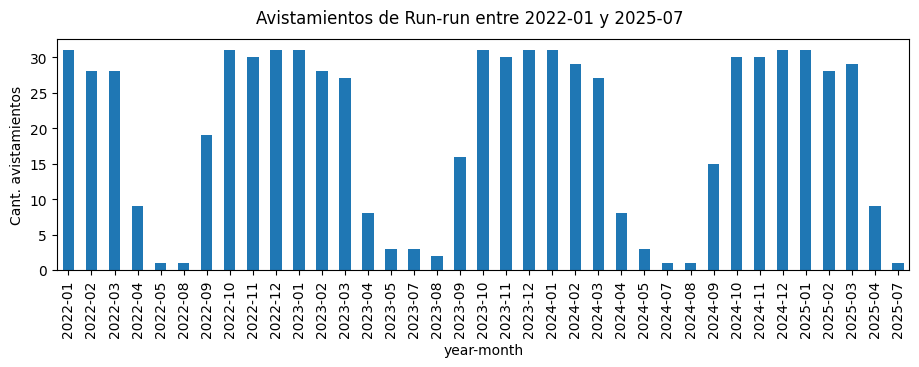

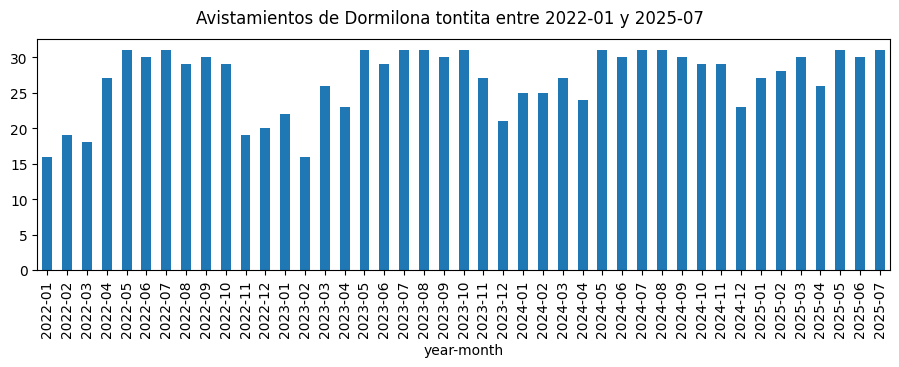

In [12]:
# Respuesta
def data_per_month(df, name):
    df_per_month = df.groupby("year-month").size()
    return df_per_month

run_run_monthly = data_per_month(run_run_df, "Run-run")
dormilona_tontita_monthly = data_per_month(dormilona_tontita_df, "Dormilona tontita")
combined_data = pd.concat([run_run_monthly, dormilona_tontita_monthly], ignore_index=True)
fig = plt.figure(figsize=(11,3))
ax = fig.add_subplot(111)
ax.set_ylabel("Cant. avistamientos")
fig.suptitle("Avistamientos de Run-run entre 2022-01 y 2025-07")
run_run_monthly.plot(kind="bar", ax = ax);
fig = plt.figure(figsize=(11,3))
ax = fig.add_subplot(111)
fig.suptitle("Avistamientos de Dormilona tontita entre 2022-01 y 2025-07")
dormilona_tontita_monthly.plot(kind="bar", ax = ax);

Analizando los gráficos, notamos que la cantidad de avistamientos de Run-run es variable con respecto a las temporadas, siendo estos comunes en verano y poco comunes en invierno.
Los avistamientos de Dormilona tontita son más estables durante todo el año, siendo más frecuentes durante los meses de invierno.

**b) (1 pto)** Grafique en un mapa de Chile la ubicación de cada avistamiento para cada especie mencionada por separado. Utilice el color de cada punto como indicador del mes de avistamiento (columna `month`). Para esto, utilice un **colormap cíclico** para representar los meses del año. Puede utilizar el colormap disponible en la siguiente celda, o bien utilizar otro (siempre y cuando sea cíclico).

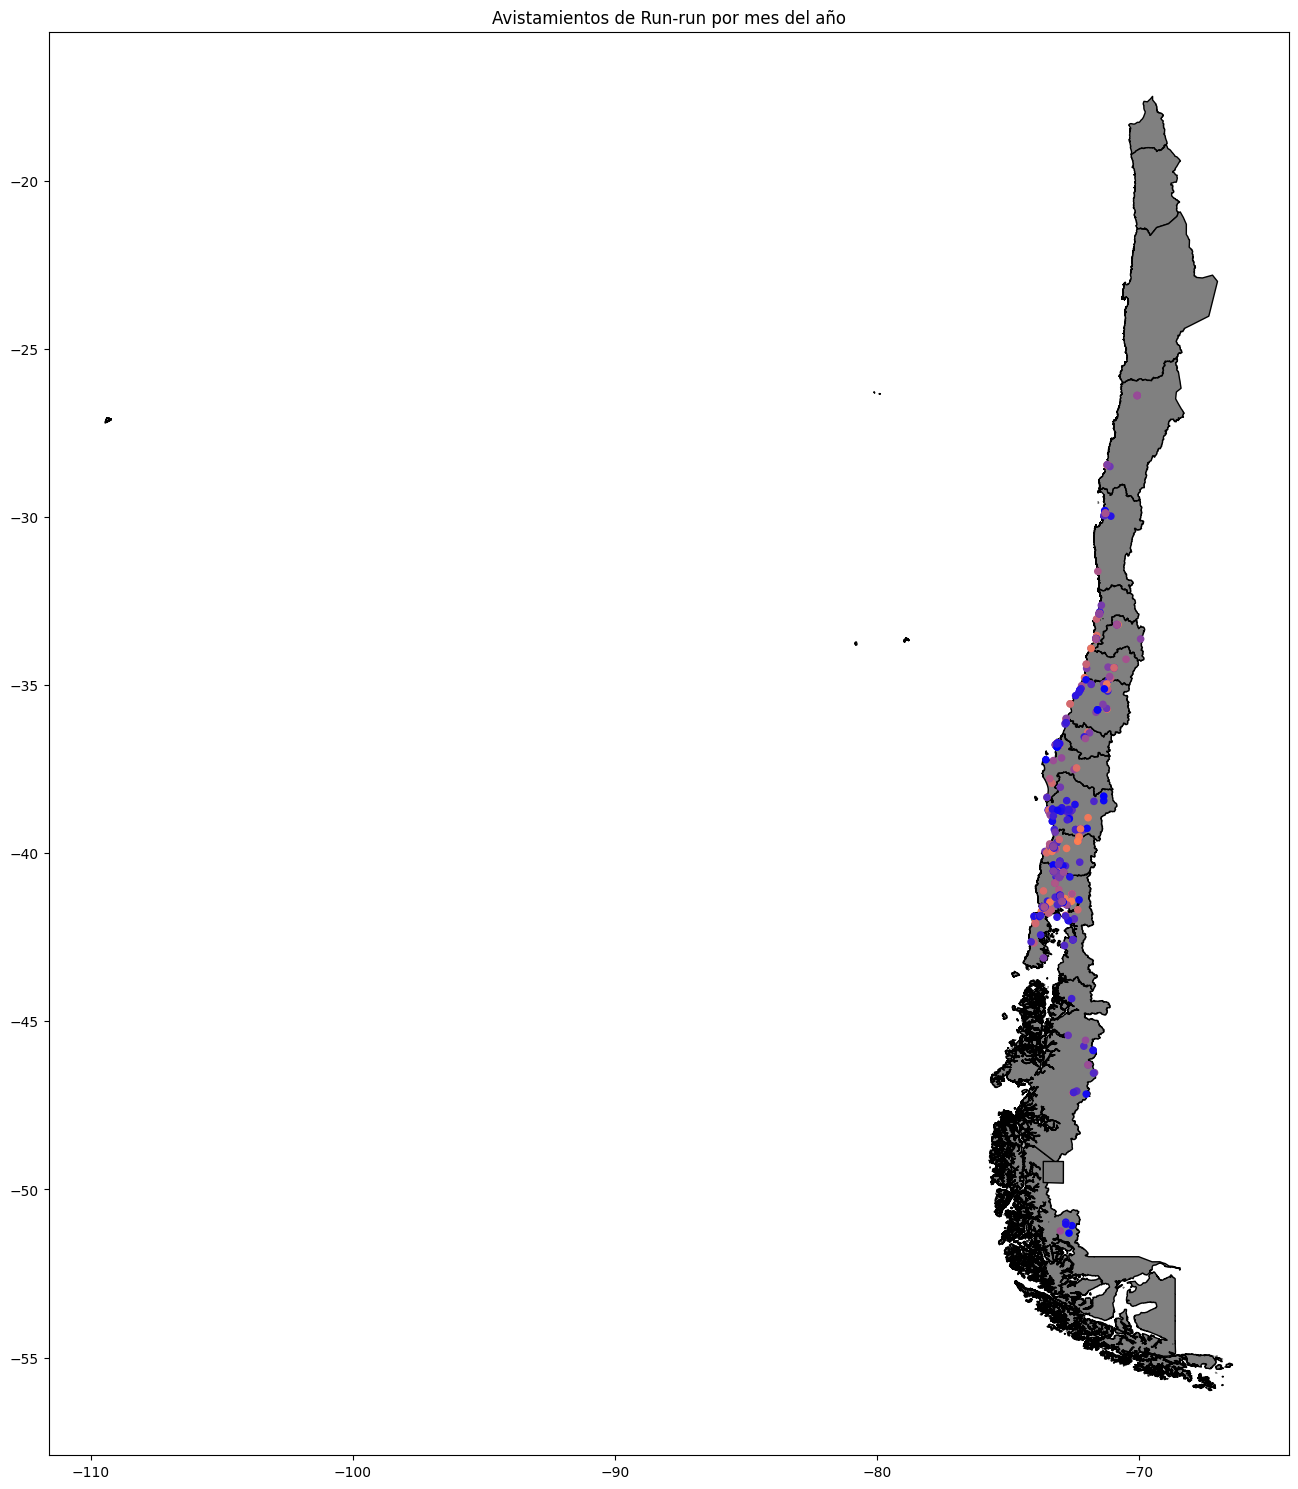

In [13]:
import matplotlib.colors as mcolors
colors = ["coral", "blue", "coral"]
positions = [0, 0.5, 1]
custom_cmap = mcolors.LinearSegmentedColormap.from_list("cyclic_cmap", list(zip(positions, colors)))

fig = plt.figure(figsize=(16, 22))
ax = fig.add_subplot(111)
ax.set_title("Avistamientos de Run-run por mes del año")
geometry = [Point(lng, lat) for lng, lat in zip(run_run_df['lng'], run_run_df['lat'])]
gdf = gpd.GeoDataFrame(run_run_df, geometry=geometry, crs='EPSG:4326')
file.plot(ax=ax, color="gray", edgecolor="black")

gdf.plot(ax=ax, c=gdf["month"], cmap=custom_cmap, markersize=20, vmin=1, vmax=12, alpha=1);

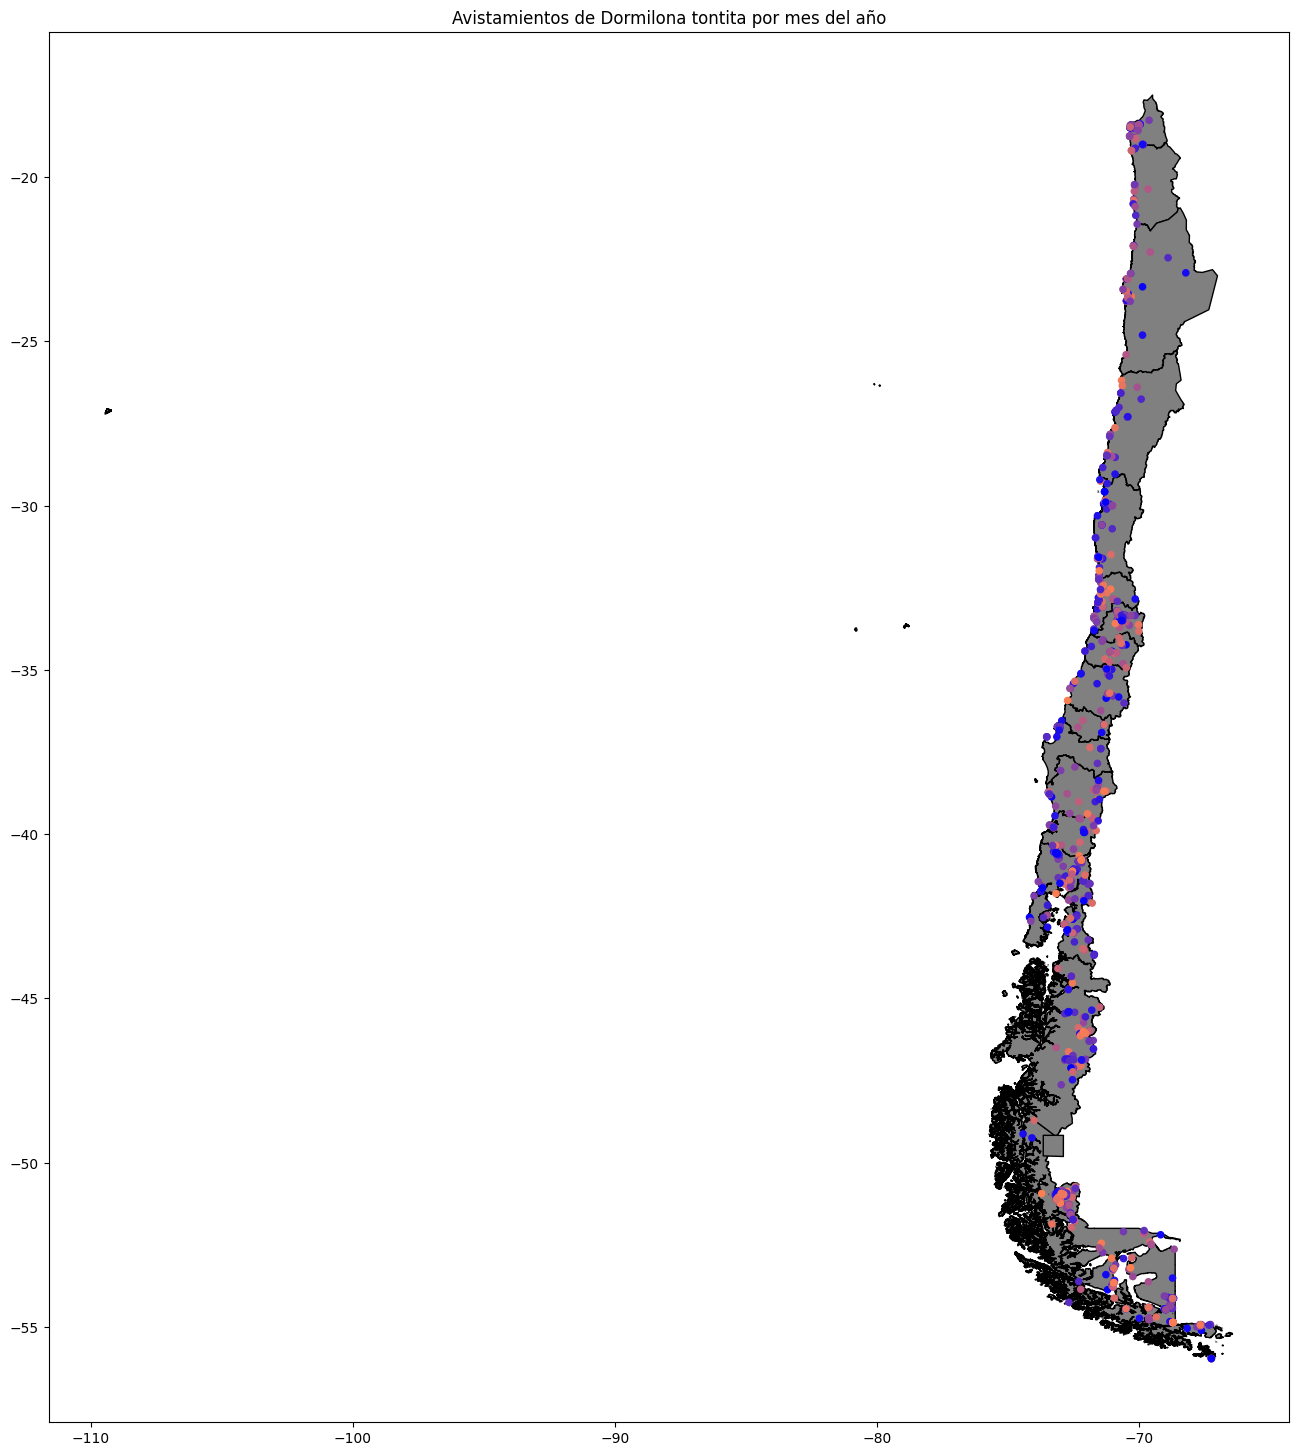

In [14]:
# Respuesta
import matplotlib.colors as mcolors
colors = ["coral", "blue", "coral"]
positions = [0, 0.5, 1]
custom_cmap = mcolors.LinearSegmentedColormap.from_list("cyclic_cmap", list(zip(positions, colors)))

fig = plt.figure(figsize=(16, 22))
ax = fig.add_subplot(111)
ax.set_title("Avistamientos de Dormilona tontita por mes del año")
geometry = [Point(lng, lat) for lng, lat in zip(dormilona_tontita_df['lng'], dormilona_tontita_df['lat'])]
gdf = gpd.GeoDataFrame(dormilona_tontita_df, geometry=geometry, crs='EPSG:4326')
file.plot(ax=ax, color="gray", edgecolor="black")

gdf.plot(ax=ax, c=gdf["month"], cmap=custom_cmap, markersize=20, vmin=1, vmax=12, alpha=1);

**c) (0.5 pts)** Describa las migraciones de estas dos especies. ¿Cómo se diferencian?

Analizando la migración de Run-run, se observa que durante los meses de invierno (azul) ocurren pocos avistamientos, y la mayoría de estos ocurren en la cordillera, en la costa, y en el extremo sur del país. En temporada de verano (coral), la mayoría de avistamientos ocurren en los valles del centro-sur del país, caracterizados por su humedad. Esto podría indicar que el ave en verano frecuenta zonas más húmedas y templadas, y en invierno probablemente migra a zonas con características similares en otros países.

Y analizando la migración de Dormilona tontita, notamos que, en todo el año, raramente se le observa en los valles del país, y su presencia fluctúa entre la cordillera y la costa. Se puede observar una cierta tendencia y es que para los meses de verano, en la zona norte, frecuenta las zonas costeras, mientras que en la zona centro-sur, el ave frecuenta la zona cordillerana y la zona de la patagonia. En invierno, el ave frecuenta la zona centro, alejándose de las zonas norte y sur. Esto podría indicar que durante el verano el ave migra hacia el norte del país.

Las migraciones de las especies se diferencian en que Run-run posiblemente migre a países vecinos durante el invierno, ya que la frecuencia de avistamientos es significativamente menor, mientras que Dormilona tontita migra hacia el norte del país durante esta temporada, haciendo que el número de avistamientos se mantenga estable durante todo el año.